<a href="https://colab.research.google.com/github/anaribeiro4/novo-repositorio/blob/main/Adaline..ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto: Reconhecimento de Letras com Adaline

### Detalhes Técnicos:
* **Modelo**: ADAptive Linear NEuron (Adaline)[cite: 112].
* **Aprendizagem**: Regra Delta baseada na saída linear[cite: 115, 135].
* **Ativação**: Função degrau com saídas bipolares (+1 ou -1)[cite: 115, 186].

Instalando fontes TrueType da Microsoft no sistema (aguarde)...
✓ Fontes configuradas com sucesso!

[Passo 1] Preparando diretórios das pastas...
[Passo 2] Construindo dataset inicial de imagens (20x20)...
[Passo 3] Treinando os classificadores Adaline para as 26 letras do alfabeto...
[Passo 4] Executando validação e gerando gráfico de convergência...

   RELATÓRIO DE DESEMPENHO (20x20)
Total de Amostras de Teste : 130
Total de Predições Corretas: 35
Acurácia Global do Sistema : 26.92%

Exemplos de erros cometidos pela rede (Top 5):
Esperado Predito
       P       H
       Q       T
       D       G
       Q       S
       Y       N


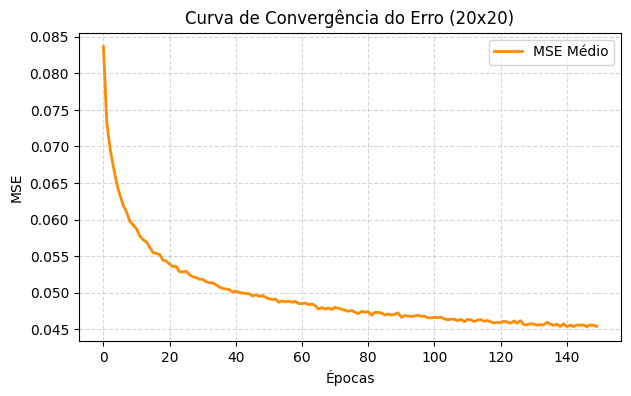

[Passo 5] Testando tolerância a falhas (Ruído Sal e Pimenta)...

      TABELA DE ROBUSTEZ COM RUÍDO            
Nível de Ruído (%)  Amostras Testadas Acurácia Obtida
                0%                130          26.92%
                5%                130          14.62%
               15%                130          12.31%
               30%                130           6.15%

      PASSO FINAL: INTERFACE DE AVALIAÇÃO DE AMOSTRAS       


In [5]:
import os
import cv2
import random
import string
import pickle
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import ipywidgets as widgets
from IPython.display import display, clear_output

# =====================================================================
# ETAPA 1: CONFIGURAÇÃO DE SISTEMA E INSTALAÇÃO DE FONTES MICROSOFT
# =====================================================================
print("Instalando fontes TrueType da Microsoft no sistema (aguarde)...")
try:
    subprocess.run("apt-get update > /dev/null 2>&1", shell=True)
    subprocess.run("echo ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true | debconf-set-selections", shell=True)
    subprocess.run("apt-get install -y ttf-mscorefonts-installer > /dev/null 2>&1", shell=True)
    subprocess.run("fc-cache -f -v > /dev/null 2>&1", shell=True)
    print("✓ Fontes configuradas com sucesso!")
except Exception as e:
    print(f"Aviso ao instalar fontes: {e}")


# =====================================================================
# ETAPA 2: PREPARAÇÃO DO AMBIENTE E GERAÇÃO DO DATASET SINTÉTICO
# =====================================================================

def preparar_ambiente():
    """Cria a estrutura de pastas necessária para o projeto."""
    for pasta in ['dados/treino', 'dados/teste', 'modelos', 'resultados']:
        if not os.path.exists(pasta):
            os.makedirs(pasta)


def gerar_variacoes_letra(letra, pasta_destino, num_variacoes=10, tamanho_imagem=20):
    """Gera variações em imagem de uma letra específica alterando fonte, tamanho e rotação."""
    fontes_requisito = {
        "Arial": "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf",
        "Times New Roman": "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf",
        "Verdana": "/usr/share/fonts/truetype/msttcorefonts/Verdana.ttf",
        "Courier": "/usr/share/fonts/truetype/msttcorefonts/Courier_New.ttf"
    }
    nomes_fontes = list(fontes_requisito.keys())

    for i in range(num_variacoes):
        nome_fonte = random.choice(nomes_fontes)
        caminho_fonte = fontes_requisito[nome_fonte]
        tamanho_fonte = int(tamanho_imagem * 0.65) + random.randint(-1, 1)

        try:
            font = ImageFont.truetype(caminho_fonte, tamanho_fonte)
        except IOError:
            font = ImageFont.load_default()

        img = Image.new('L', (tamanho_imagem, tamanho_imagem), color=255)
        draw = ImageDraw.Draw(img)

        try:
            bbox = draw.textbbox((0, 0), letra, font=font)
            w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
        except AttributeError:
            w, h = draw.textsize(letra, font=font)

        pos_x = (tamanho_imagem - w) // 2 + random.randint(-1, 1)
        pos_y = (tamanho_imagem - h) // 2 + random.randint(-1, 1)

        draw.text((pos_x, pos_y), letra, fill=0, font=font)

        angulo = random.randint(-8, 8)
        img = img.rotate(angulo, resample=Image.BICUBIC, fillcolor=255)

        nome_arquivo = f"{letra}_{nome_fonte.replace(' ', '')}_{i}.png"
        img.save(os.path.join(pasta_destino, nome_arquivo))


def construir_dataset(tamanho_imagem=20):
    """Limpa as pastas e reconstrói o dataset com imagens de treino e teste."""
    if os.path.exists('dados/treino'):
        for f in os.listdir('dados/treino'): os.remove(os.path.join('dados/treino', f))
    if os.path.exists('dados/teste'):
        for f in os.listdir('dados/teste'): os.remove(os.path.join('dados/teste', f))

    alfabeto = string.ascii_uppercase
    for letra in alfabeto:
        gerar_variacoes_letra(letra, 'dados/treino', num_variacoes=15, tamanho_imagem=tamanho_imagem)
        gerar_variacoes_letra(letra, 'dados/teste', num_variacoes=5, tamanho_imagem=tamanho_imagem)


# =====================================================================
# ETAPA 3: PROCESSAMENTO DE IMAGENS E MAPEAMENTO BIPOLAR CRÍTICO
# =====================================================================

def extrair_vetor_caracteristicas(caminho_imagem, tamanho_padrao=(20, 20)):
    """Lê a imagem, binariza e mapeia para valores bipolares (-1.0 e 1.0)."""
    img = cv2.imread(caminho_imagem)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
    resized = cv2.resize(binary, tamanho_padrao, interpolation=cv2.INTER_AREA)

    # CRUCIAL PARA ADALINE: Mapeia pixel ativo para 1.0 e fundo para -1.0
    vetor_final = np.where(resized > 0, 1.0, -1.0)

    return vetor_final.flatten()


def carregar_dados_pasta(pasta, dim_atual=(20, 20)):
    """Varre a pasta extraindo as características bipolares e rótulos."""
    X = []
    y = []
    for nome_arquivo in os.listdir(pasta):
        if nome_arquivo.endswith('.png'):
            letra = nome_arquivo.split('_')[0]
            vetor = extrair_vetor_caracteristicas(os.path.join(pasta, nome_arquivo), tamanho_padrao=dim_atual)
            if vetor is not None:
                X.append(vetor)
                y.append(letra)
    return np.array(X), np.array(y)


# =====================================================================
# ETAPA 4: IMPLEMENTAÇÃO DO NEURÔNIO ADALINE
# =====================================================================

class Adaline:
    def __init__(self, n_features, lr=0.0005, epochs=150):
        self.lr = lr
        self.epochs = epochs
        self.w = np.random.uniform(-0.01, 0.01, n_features)
        self.b = np.random.uniform(-0.01, 0.01)
        self.historico_erros = []

    def funcao_linear(self, x):
        return np.dot(x, self.w) + self.b

    def funcao_degrau_bipolar(self, y_linear):
        return np.where(y_linear >= 0, 1, -1)

    def treinar(self, X, t):
        self.historico_erros = []
        for epoca in range(self.epochs):
            erro_quadratico_epoca = 0.0
            indices = np.arange(len(X))
            np.random.shuffle(indices)

            for idx in indices:
                x_amostra = X[idx]
                t_alvo = t[idx]

                y_linear = self.funcao_linear(x_amostra)
                erro = t_alvo - y_linear
                erro_quadratico_epoca += 0.5 * (erro ** 2)

                # Regra Delta de Widrow-Hoff
                self.w += self.lr * erro * x_amostra
                self.b += self.lr * erro

            self.historico_erros.append(erro_quadratico_epoca / len(X))


# =====================================================================
# ETAPA 5: FLUXO DE TREINAMENTO E CLASSIFICAÇÃO MULTI-CLASSE
# =====================================================================

def treinar_sistema_completo(lr=0.0005, epochs=150, dim_atual=(20, 20)):
    X_treino, y_treino = carregar_dados_pasta('dados/treino', dim_atual=dim_atual)

    if len(X_treino) == 0:
        return None, None

    alfabeto = list(string.ascii_uppercase)
    modelos_adaline = {}
    mse_acumulado_epocas = np.zeros(epochs)

    for letra in alfabeto:
        t_bipolar = np.where(y_treino == letra, 1, -1)
        modelo = Adaline(n_features=X_treino.shape[1], lr=lr, epochs=epochs)
        modelo.treinar(X_treino, t_bipolar)
        modelos_adaline[letra] = modelo
        mse_acumulado_epocas += np.array(modelo.historico_erros)

    with open('modelos/rede_adaline_caracteres.pkl', 'wb') as f:
        pickle.dump(modelos_adaline, f)

    return modelos_adaline, (mse_acumulado_epocas / len(alfabeto))


def classificar_caractere(vetor_caracteristicas, modelos):
    maior_score = float('-inf')
    letra_predita = None

    for letra, neuronio in modelos.items():
        score_linear = neuronio.funcao_linear(vetor_caracteristicas)
        if score_linear > maior_score:
            maior_score = score_linear
            letra_predita = letra

    return letra_predita


# =====================================================================
# ETAPA 6: ROBUSTEZ, RUÍDOS E VALIDAÇÃO GERAL
# =====================================================================

def aplicar_ruido_sal_pimenta(X_matriz, porcentagem=0.1):
    X_ruidoso = X_matriz.copy()
    amostras, features = X_ruidoso.shape
    n_pixels_mudar = int(features * porcentagem)

    for i in range(amostras):
        indices = np.random.choice(features, n_pixels_mudar, replace=False)
        # Inversão lógica bipolar (-1 vira 1 e vice-versa)
        X_ruidoso[i, indices] = np.where(X_ruidoso[i, indices] == 1.0, -1.0, 1.0)

    return X_ruidoso


def avaliar_sistema_completo(modelos, mse_historico, dim_atual=(20, 20)):
    X_teste, y_teste = carregar_dados_pasta('dados/teste', dim_atual=dim_atual)

    acertos = 0
    predicoes = []

    for x, alvo in zip(X_teste, y_teste):
        predicao = classificar_caractere(x, modelos)
        predicoes.append(predicao)
        if predicao == alvo:
            acertos += 1

    acuracia = (acertos / len(y_teste)) * 100

    print("\n==============================================")
    print(f"   RELATÓRIO DE DESEMPENHO ({dim_atual[0]}x{dim_atual[1]})")
    print("==============================================")
    print(f"Total de Amostras de Teste : {len(y_teste)}")
    print(f"Total de Predições Corretas: {acertos}")
    print(f"Acurácia Global do Sistema : {acuracia:.2f}%")
    print("==============================================")

    df_resultados = pd.DataFrame({'Esperado': y_teste, 'Predito': predicoes})
    erros = df_resultados[df_resultados['Esperado'] != df_resultados['Predito']]
    if not erros.empty:
        print(f"\nExemplos de erros cometidos pela rede (Top 5):\n{erros.head(5).to_string(index=False)}")
    else:
        print("\n✓ Incrível! A rede obteve 100% de acerto nas imagens de teste.")

    plt.figure(figsize=(7, 4))
    plt.plot(mse_historico, color='darkorange', linewidth=2, label='MSE Médio')
    plt.title(f'Curva de Convergência do Erro ({dim_atual[0]}x{dim_atual[1]})')
    plt.xlabel('Épocas')
    plt.ylabel('MSE')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    return acuracia, X_teste, y_teste


def rodar_testes_robustez(modelos, X_teste, y_teste):
    niveis_ruido = [0.0, 0.05, 0.15, 0.30]
    tabela_resultados = []

    for nivel in niveis_ruido:
        X_test_ruido = aplicar_ruido_sal_pimenta(X_teste, porcentagem=nivel)

        acertos = 0
        for x, alvo in zip(X_test_ruido, y_teste):
            if classificar_caractere(x, modelos) == alvo:
                acertos += 1

        acuracia = (acertos / len(y_teste)) * 100
        tabela_resultados.append({
            "Nível de Ruído (%)": f"{nivel * 100:.0f}%",
            "Amostras Testadas": len(y_teste),
            "Acurácia Obtida": f"{acuracia:.2f}%"
        })

    df_robustez = pd.DataFrame(tabela_resultados)
    print("\n==============================================")
    print("      TABELA DE ROBUSTEZ COM RUÍDO            ")
    print("==============================================")
    print(df_robustez.to_string(index=False))
    print("==============================================")


# =====================================================================
# ETAPA 7: INTERFACE GRÁFICA INTERATIVA COMPATÍVEL COM WEB / COLAB
# =====================================================================

def iniciar_interface_colab(modelos, dim_atual=(20, 20)):
    """Gera uma interface limpa e reativa via ipywidgets para o navegador."""
    output_area = widgets.Output()

    arquivos_teste = [f for f in os.listdir('dados/teste') if f.endswith('.png')]
    dicionario_letras = {}

    for arq in arquivos_teste:
        letra_chave = arq.split('_')[0]
        if letra_chave not in dicionario_letras:
            dicionario_letras[letra_chave] = []
        dicionario_letras[letra_chave].append(arq)

    letras_disponiveis = sorted(list(dicionario_letras.keys()))
    for letra in letras_disponiveis:
        dicionario_letras[letra] = sorted(dicionario_letras[letra])

    dropdown_letra = widgets.Dropdown(
        options=letras_disponiveis,
        value=letras_disponiveis[0],
        description='Escolha a Letra:',
        style={'description_width': 'initial'}
    )

    dropdown_amostra = widgets.Dropdown(
        options=[f"Amostra {i+1}" for i in range(len(dicionario_letras[letras_disponiveis[0]]))],
        description='Variação:',
        style={'description_width': 'initial'}
    )

    botao = widgets.Button(
        description='Classificar Imagem',
        button_style='success',
        icon='check',
        layout=widgets.Layout(margin='10px 0px 0px 0px', width='200px')
    )

    def ao_mudar_letra(change):
        nova_letra = change['new']
        qtd_amostras = len(dicionario_letras[nova_letra])
        dropdown_amostra.options = [f"Amostra {i+1}" for i in range(qtd_amostras)]

    dropdown_letra.observe(ao_mudar_letra, names='value')

    def executar_classificacao(b):
        with output_area:
            clear_output()

            letra_escolhida = dropdown_letra.value
            texto_amostra = dropdown_amostra.value
            idx_amostra = int(texto_amostra.split(' ')[1]) - 1

            imagem_selecionada = dicionario_letras[letra_escolhida][idx_amostra]
            caminho_completo = os.path.join('dados/teste', imagem_selecionada)

            vetor = extrair_vetor_caracteristicas(caminho_completo, tamanho_padrao=dim_atual)
            if vetor is not None:
                letra_predita = classificar_caractere(vetor, modelos)

                fig, ax = plt.subplots(1, 2, figsize=(7, 3.5))
                img_exibicao = cv2.imread(caminho_completo, cv2.IMREAD_GRAYSCALE)

                ax[0].imshow(img_exibicao, cmap='gray')
                ax[0].set_title(f"Imagem Real: Letra {letra_escolhida}", fontsize=11, fontweight='bold')
                ax[0].axis('off')

                cor_resultado = 'green' if letra_predita == letra_escolhida else 'red'
                ax[1].text(0.5, 0.5, f"Predição da Rede:\nLetra {letra_predita}",
                           fontsize=18, fontweight='bold', color=cor_resultado,
                           ha='center', va='center')
                ax[1].axis('off')

                plt.tight_layout()
                plt.show()
            else:
                print("Erro ao carregar a imagem selecionada.")

    botao.on_click(executar_classificacao)

    print("\n" + "="*60)
    print("      PASSO FINAL: INTERFACE DE AVALIAÇÃO DE AMOSTRAS       ")
    print("="*60)
    display(widgets.VBox([dropdown_letra, dropdown_amostra, botao, output_area]))


# =====================================================================
# PIPELINE PRINCIPAL DE EXECUÇÃO
# =====================================================================

if __name__ == "__main__":
    print("\n[Passo 1] Preparando diretórios das pastas...")
    preparar_ambiente()

    dimensao_padrao = (20, 20)
    print(f"[Passo 2] Construindo dataset inicial de imagens ({dimensao_padrao[0]}x{dimensao_padrao[1]})...")
    construir_dataset(tamanho_imagem=dimensao_padrao[0])

    print("[Passo 3] Treinando os classificadores Adaline para as 26 letras do alfabeto...")
    modelos_treinados, historico_mse = treinar_sistema_completo(lr=0.0005, epochs=150, dim_atual=dimensao_padrao)

    if modelos_treinados is not None:
        print("[Passo 4] Executando validação e gerando gráfico de convergência...")
        acuracia, X_test, y_test = avaliar_sistema_completo(modelos_treinados, historico_mse, dim_atual=dimensao_padrao)

        print("[Passo 5] Testando tolerância a falhas (Ruído Sal e Pimenta)...")
        rodar_testes_robustez(modelos_treinados, X_test, y_test)

        # Inicia a interface organizada de A a Z para testes individuais sem travar o menu do Colab
        iniciar_interface_colab(modelos_treinados, dim_atual=dimensao_padrao)
    else:
        print("Erro: Falha no carregamento dos dados de treino.")